In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.jpg to images.jpg


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving download (7).jpg to download (7).jpg


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_image(path, size=256):
    image = Image.open(path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    return image.to(device)

content_img = load_image("content.jpg")
style_img = load_image("style.jpg")

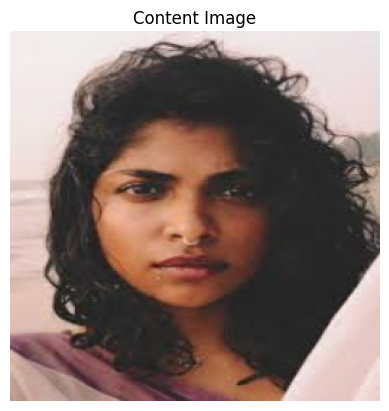

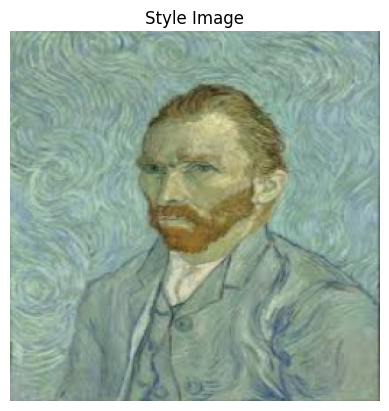

In [ ]:
def show(img, title):
    image = img.cpu().squeeze().permute(1,2,0)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

show(content_img, "Content Image")
show(style_img, "Style Image")

In [ ]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

In [ ]:
content_layer = '21'

style_layers = {
    '0': 'conv1_1',
    '5': 'conv2_1',
    '10': 'conv3_1',
    '19': 'conv4_1',
    '28': 'conv5_1'
}

In [ ]:
def get_features(image, model):
    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)

        if name == content_layer:
            features['content'] = x

        if name in style_layers:
            features[style_layers[name]] = x

    return features

In [ ]:
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h * w)
    return torch.mm(tensor, tensor.t()) / (c * h * w)

In [ ]:
def content_loss(gen, content):
    return torch.mean((gen - content) ** 2)

def style_loss(gen, style):
    G = gram_matrix(gen)
    A = gram_matrix(style)
    return torch.mean((G - A) ** 2)

In [ ]:
target = content_img.clone().requires_grad_(True).to(device)

In [ ]:
optimizer = optim.Adam([target], lr=0.003)

content_weight = 1e4
style_weight = 1e6

epochs = 200

In [ ]:
content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)

for epoch in range(epochs):

    target_features = get_features(target, vgg)

    # Content loss
    c_loss = content_loss(
        target_features['content'],
        content_features['content']
    )

    # Style loss
    s_loss = 0
    for layer in style_layers.values():
        s_loss += style_loss(
            target_features[layer],
            style_features[layer]
        )

    # Total loss
    total_loss = content_weight * c_loss + style_weight * s_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # Keep pixels valid
    with torch.no_grad():
        target.clamp_(0, 1)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss.item()}")

Epoch 0, Loss: 4.310328006744385
Epoch 50, Loss: 7.658330917358398
Epoch 100, Loss: 4.98408842086792
Epoch 150, Loss: 4.564123153686523


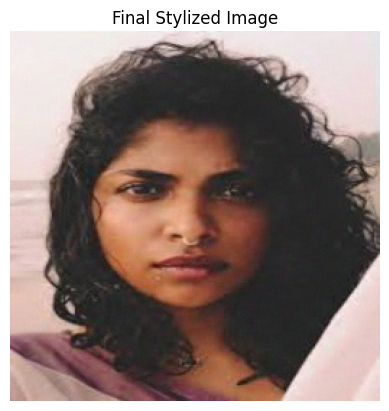

In [ ]:

def show(img, title):
    image = img.detach().cpu().squeeze().permute(1,2,0)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()
show(target, "Final Stylized Image")

In [ ]:
output_img = target.clone().detach().cpu().squeeze(0)
output_img = transforms.ToPILImage()(output_img)
output_img.save("output.png")